In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# 1. Load the cleaned dataset
df = pd.read_csv('Cleaned_Maritime_Data.csv')

In [27]:
# 2. Group the data by Region and Ship_Type, calculating the mean of Median_Port_Time
# We exclude 'World' from the visualization to focus on specific economic regions
df_filtered = df[df['Region'] != 'World']
grouped_data = df_filtered.groupby(['Region', 'Ship_Type'])['Median_Port_Time'].mean().reset_index()

In [28]:
# 3. Pivot the data to create a matrix suitable for a heatmap
heatmap_data = grouped_data.pivot(index='Ship_Type', columns='Region', values='Median_Port_Time')

In [29]:
print("Data Preview:")
print(heatmap_data.head())

Data Preview:
Region                          Australia  Canada   China  Croatia  Denmark  \
Ship_Type                                                                     
All ships                          1.5625  0.6575  1.0925   1.3325   0.7475   
Container ships                    1.5500  1.6600  0.6700   0.7025   0.5875   
Dry breakbulk carriers             2.0575  0.2775  1.4475   2.6875   0.8075   
Dry bulk carriers                  1.6750  0.3800  2.0425   2.6825   0.8175   
Liquefied natural gas carriers     1.2075     NaN  1.1925   2.1425      NaN   

Region                          France  Germany  Greece  Indonesia   Italy  \
Ship_Type                                                                    
All ships                       1.1700   0.6950  0.8250      1.265  1.3125   
Container ships                 0.9675   1.1175  1.0575      0.985  0.9450   
Dry breakbulk carriers          1.5275   0.6600  1.1450      1.160  1.9600   
Dry bulk carriers               3.1450   2

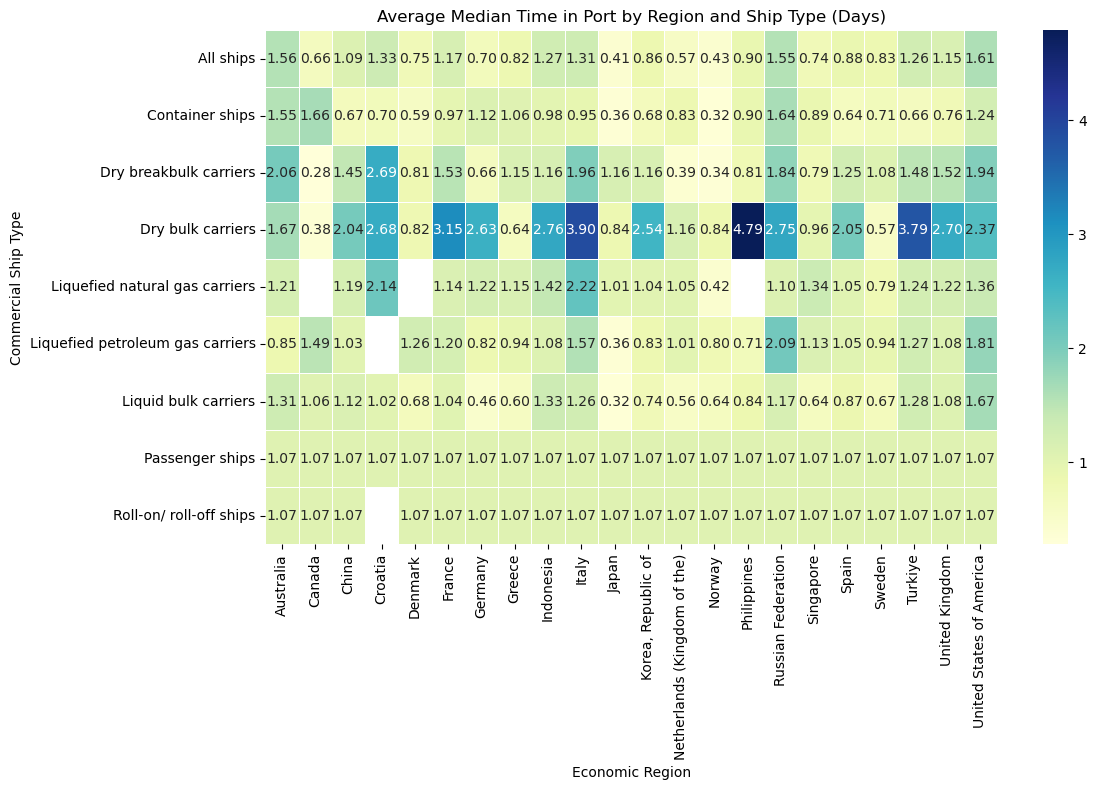

In [30]:
# 4. Generate the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Average Median Time in Port by Region and Ship Type (Days)')
plt.ylabel('Commercial Ship Type')
plt.xlabel('Economic Region')
plt.tight_layout()
plt.show()